In [4]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sc

df = pd.read_csv("mysql_10000_rows.csv")

# EDA

In [2]:
df.shape

(10000, 6)

In [3]:
df.head()

,id,name,age,city,department,salary
0,1,Rahul,35,Jaipur,HR,127877
1,2,Anuj,50,Delhi,IT,31521
2,3,Vikas,51,Hyderabad,Operations,36092
3,4,Rohit,26,Hyderabad,HR,61376
4,5,Rohit,20,Delhi,Finance,112952


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   id          10000 non-null  int64
 1   name        10000 non-null  str  
 2   age         10000 non-null  int64
 3   city        10000 non-null  str  
 4   department  10000 non-null  str  
 5   salary      10000 non-null  int64
dtypes: int64(3), str(3)
memory usage: 636.3 KB


In [5]:
df.describe()

,id,age,salary
count,10000.00000,10000.000000,10000.000000
mean,5000.50000,37.414100,87847.983200
std,2886.89568,10.392537,35982.928899
min,1.00000,20.000000,25033.000000
25%,2500.75000,28.000000,57071.750000
50%,5000.50000,37.000000,87685.000000
75%,7500.25000,46.000000,118995.500000
max,10000.00000,55.000000,149986.000000


In [6]:
df.dtypes

id            int64
name            str
age           int64
city            str
department      str
salary        int64
dtype: object

In [7]:
df.isnull().sum()

id            0
name          0
age           0
city          0
department    0
salary        0
dtype: int64

In [8]:
df.columns

Index(['id', 'name', 'age', 'city', 'department', 'salary'], dtype='str')

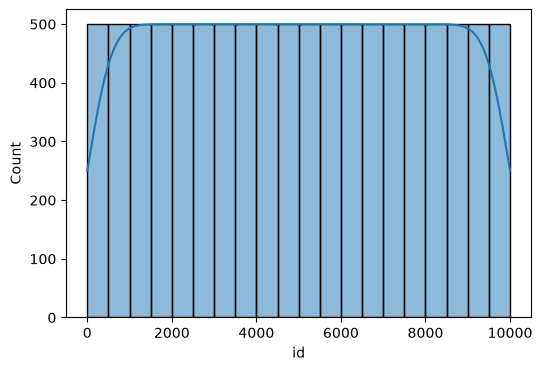

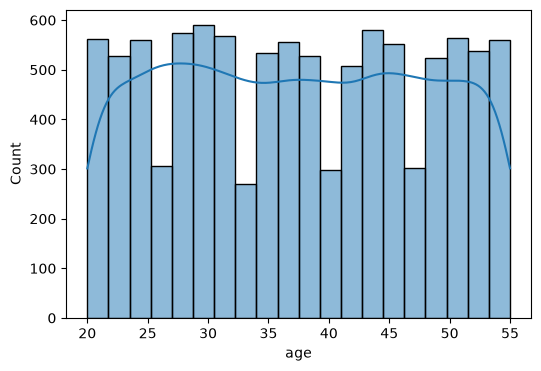

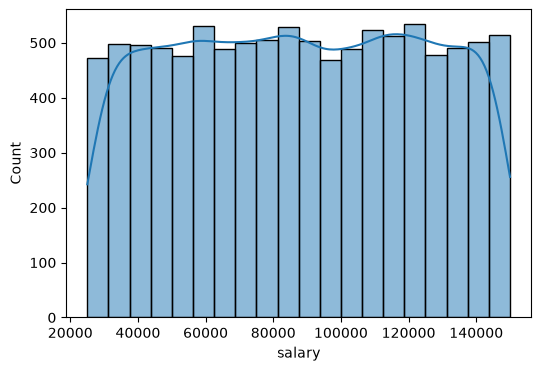

In [5]:
numerical = ['id','age','salary']

for i in numerical:
    plt.figure(figsize=(6,4))
    sc.histplot(df[i],kde=True, bins=20)

<Axes: xlabel='department', ylabel='count'>

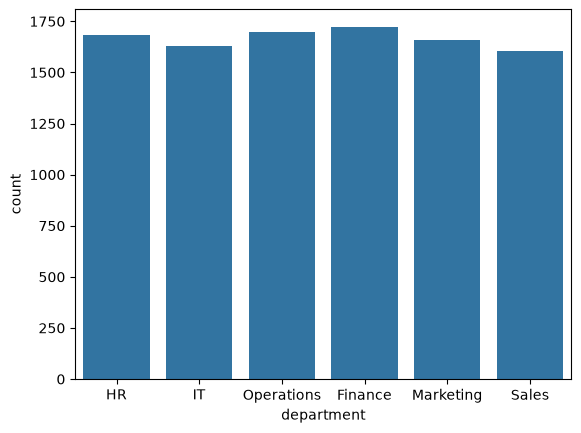

In [6]:
sc.countplot(x= df['department'])

In [8]:
df['department'].value_counts()

department
Finance       1722
Operations    1700
HR            1683
Marketing     1658
IT            1631
Sales         1606
Name: count, dtype: int64

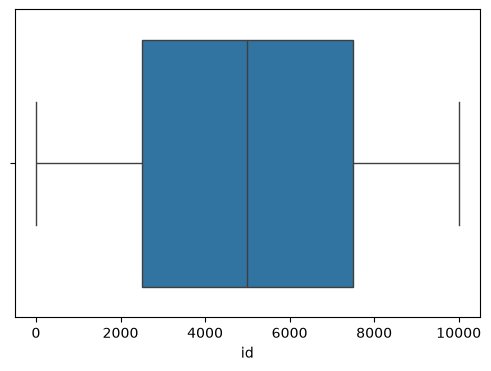

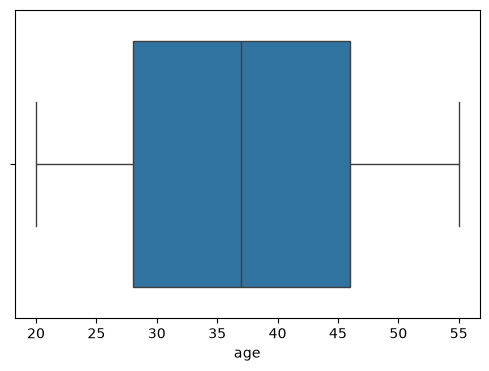

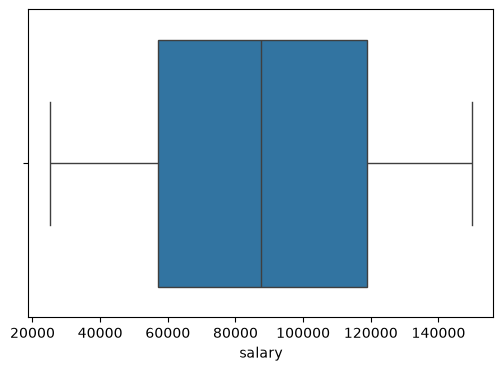

In [7]:
for i in numerical:
    plt.figure(figsize=(6,4))
    sc.boxplot(x= df[i])

In [11]:
df['age'].corr(df['salary'])

np.float64(-0.0015203900210716051)

# DATA CLEANING AND PREPROCESSING


In [31]:
df2 = df.copy()

In [32]:
df2.head()

,id,name,age,city,department,salary
0,1,Rahul,35,Jaipur,HR,127877
1,2,Anuj,50,Delhi,IT,31521
2,3,Vikas,51,Hyderabad,Operations,36092
3,4,Rohit,26,Hyderabad,HR,61376
4,5,Rohit,20,Delhi,Finance,112952


In [33]:
df2.drop_duplicates()

,id,name,age,city,department,salary
0,1,Rahul,35,Jaipur,HR,127877
1,2,Anuj,50,Delhi,IT,31521
2,3,Vikas,51,Hyderabad,Operations,36092
3,4,Rohit,26,Hyderabad,HR,61376
4,5,Rohit,20,Delhi,Finance,112952
...,...,...,...,...,...,...
9995,9996,Rahul,34,Lucknow,Marketing,105757
9996,9997,Vikas,44,Jaipur,Finance,146224
9997,9998,Rahul,39,Hyderabad,Finance,34734
9998,9999,Neha,45,Delhi,Finance,70210


In [34]:
df2 = pd.get_dummies(df2, columns=['department','city','name'],drop_first=True, dtype=int)

In [40]:
pd.set_option("display.max_rows",None)
pd.set_option("display.max_columns",None)

In [41]:
df2.head()

,id,age,salary,department_HR,department_IT,department_Marketing,department_Operations,department_Sales,city_Chennai,city_Delhi,city_Hyderabad,city_Jaipur,city_Kolkata,city_Lucknow,city_Mumbai,city_Noida,city_Pune,name_Anuj,name_Karan,name_Neha,name_Pooja,name_Priya,name_Rahul,name_Rohit,name_Simran,name_Vikas
0,1,35,127877,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0
1,2,50,31521,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
2,3,51,36092,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
3,4,26,61376,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
4,5,20,112952,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0


In [ ]:
sc.heatmap(df.corr(numeric_only=True), annot= True)

# FEATURE ENGINEERING AND EXTRACTIONS

In [44]:
df2['salary_category'] = pd.cut(
    df2['salary'],
    bins=[20000, 45000, 90000, float("inf")],
    labels=["Low","Medium","High"]
)

In [45]:
df2.head()

,id,age,salary,department_HR,department_IT,department_Marketing,department_Operations,department_Sales,city_Chennai,city_Delhi,city_Hyderabad,city_Jaipur,city_Kolkata,city_Lucknow,city_Mumbai,city_Noida,city_Pune,name_Anuj,name_Karan,name_Neha,name_Pooja,name_Priya,name_Rahul,name_Rohit,name_Simran,name_Vikas,salary_category
0,1,35,127877,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,High
1,2,50,31521,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,Low
2,3,51,36092,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,Low
3,4,26,61376,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,Medium
4,5,20,112952,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,High


In [46]:
from sklearn.preprocessing import StandardScaler
cols = ['age']

scal = StandardScaler()

df2[cols] = scal.fit_transform(df2[cols])

In [47]:
df2.head()

,id,age,salary,department_HR,department_IT,department_Marketing,department_Operations,department_Sales,city_Chennai,city_Delhi,city_Hyderabad,city_Jaipur,city_Kolkata,city_Lucknow,city_Mumbai,city_Noida,city_Pune,name_Anuj,name_Karan,name_Neha,name_Pooja,name_Priya,name_Rahul,name_Rohit,name_Simran,name_Vikas,salary_category
0,1,-0.232303,127877,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,High
1,2,1.211112,31521,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,Low
2,3,1.307340,36092,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,Low
3,4,-1.098353,61376,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,Medium
4,5,-1.675719,112952,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,High


In [48]:
df2.columns

Index(['id', 'age', 'salary', 'department_HR', 'department_IT',
       'department_Marketing', 'department_Operations', 'department_Sales',
       'city_Chennai', 'city_Delhi', 'city_Hyderabad', 'city_Jaipur',
       'city_Kolkata', 'city_Lucknow', 'city_Mumbai', 'city_Noida',
       'city_Pune', 'name_Anuj', 'name_Karan', 'name_Neha', 'name_Pooja',
       'name_Priya', 'name_Rahul', 'name_Rohit', 'name_Simran', 'name_Vikas',
       'salary_category'],
      dtype='str')

In [50]:
from scipy.stats import pearsonr

clean = [ 'age','department_HR', 'department_IT',
       'department_Marketing', 'department_Operations', 'department_Sales',
       'city_Chennai', 'city_Delhi', 'city_Hyderabad', 'city_Jaipur',
       'city_Kolkata', 'city_Lucknow', 'city_Mumbai', 'city_Noida',
       'city_Pune', 'name_Anuj', 'name_Karan', 'name_Neha', 'name_Pooja',
       'name_Priya', 'name_Rahul', 'name_Rohit', 'name_Simran', 'name_Vikas'
       ]

correlation = {
    feature : pearsonr(df2[feature], df2['salary'])[0]
    for feature in clean
}

correlation_df = pd.DataFrame(list(correlation.items()), columns=['Feature','person_correlation'])
correlation_df.sort_values(by = 'person_correlation',ascending = False)

,Feature,person_correlation
11,city_Lucknow,0.017908
15,name_Anuj,0.015386
21,name_Rohit,0.013490
20,name_Rahul,0.009757
9,city_Jaipur,0.007856
1,department_HR,0.005834
7,city_Delhi,0.004746
12,city_Mumbai,0.003845
5,department_Sales,0.003690
0,age,-0.001520


In [52]:
cat_features = ['department_HR', 'department_IT',
       'department_Marketing', 'department_Operations', 'department_Sales',
       'city_Chennai', 'city_Delhi', 'city_Hyderabad', 'city_Jaipur',
       'city_Kolkata', 'city_Lucknow', 'city_Mumbai', 'city_Noida',
       'city_Pune', 'name_Anuj', 'name_Karan', 'name_Neha', 'name_Pooja',
       'name_Priya', 'name_Rahul', 'name_Rohit', 'name_Simran', 'name_Vikas']

In [53]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

df2['salary_bin'] = pd.qcut(df2['salary'], q=4, labels=False)
chi2_results = {}

for col in cat_features:
    contingency = pd.crosstab(df2[col], df2['salary_bin'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')
chi2_df

,chi2_statistic,p_value,Decision
city_Chennai,11.547925,0.009104,Reject Null (Keep Feature)
name_Simran,8.674938,0.03394,Reject Null (Keep Feature)
name_Rohit,6.66778,0.083275,Accept Null (Drop Feature)
department_HR,6.471865,0.090779,Accept Null (Drop Feature)
name_Anuj,4.164296,0.244261,Accept Null (Drop Feature)
name_Pooja,3.964059,0.265371,Accept Null (Drop Feature)
city_Noida,3.463715,0.325499,Accept Null (Drop Feature)
department_Marketing,3.311393,0.34606,Accept Null (Drop Feature)
name_Priya,2.971969,0.395967,Accept Null (Drop Feature)
department_IT,2.604426,0.456714,Accept Null (Drop Feature)


In [55]:
df2.head()

,id,age,salary,department_HR,department_IT,department_Marketing,department_Operations,department_Sales,city_Chennai,city_Delhi,city_Hyderabad,city_Jaipur,city_Kolkata,city_Lucknow,city_Mumbai,city_Noida,city_Pune,name_Anuj,name_Karan,name_Neha,name_Pooja,name_Priya,name_Rahul,name_Rohit,name_Simran,name_Vikas,salary_category,salary_bin
0,1,-0.232303,127877,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,High,3
1,2,1.211112,31521,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,Low,0
2,3,1.307340,36092,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,Low,0
3,4,-1.098353,61376,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,Medium,1
4,5,-1.675719,112952,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,High,2


In [56]:
name_columns = [
    col for col in df2.columns
    if col.startswith("name_")
]

df2 = df2.drop(columns=name_columns)

In [57]:
df2.columns

Index(['id', 'age', 'salary', 'department_HR', 'department_IT',
       'department_Marketing', 'department_Operations', 'department_Sales',
       'city_Chennai', 'city_Delhi', 'city_Hyderabad', 'city_Jaipur',
       'city_Kolkata', 'city_Lucknow', 'city_Mumbai', 'city_Noida',
       'city_Pune', 'salary_category', 'salary_bin'],
      dtype='str')

In [58]:
df2.head()

,id,age,salary,department_HR,department_IT,department_Marketing,department_Operations,department_Sales,city_Chennai,city_Delhi,city_Hyderabad,city_Jaipur,city_Kolkata,city_Lucknow,city_Mumbai,city_Noida,city_Pune,salary_category,salary_bin
0,1,-0.232303,127877,1,0,0,0,0,0,0,0,1,0,0,0,0,0,High,3
1,2,1.211112,31521,0,1,0,0,0,0,1,0,0,0,0,0,0,0,Low,0
2,3,1.307340,36092,0,0,0,1,0,0,0,1,0,0,0,0,0,0,Low,0
3,4,-1.098353,61376,1,0,0,0,0,0,0,1,0,0,0,0,0,0,Medium,1
4,5,-1.675719,112952,0,0,0,0,0,0,1,0,0,0,0,0,0,0,High,2
